In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [6]:
DF = pd.read_csv(r"expectation_decider_dataset.csv")

In [8]:
DF.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,11.0,82.1,Yes,36,Fail
1,6.7,94.9,No,42,Fail
2,12.4,79.1,Yes,55,Pass
3,13.0,85.7,No,54,Fail
4,3.8,53.4,No,75,Fail


# **Q1 Understanding the Basics**

# Probability is mathematical measure of how likely an event occurs.

# *Key probability terminology

# EXPERIMENT : A process that produce an outcomes

# OUTCOME : A SINGLE SPECIFIC RESULT THAT COMES FROM AN EVENT

# SAMPLE SPACE : SET OF ALL POSSIBLE OUTCOMES OF AN EXPERIMENT

# EVENT : A SPECIFIC OUTCOMES

# Q1 Probability that a student studies more than 10 hours and fails.

In [15]:
A = len(DF[(DF["study_hours"] > 10) & (DF["final_exam_pass"] == "Fail")])
B = len(DF)
q = A / B

print(f"probability: {q}")

probability: 0.32


# Q2 probability of failing the exam

In [18]:
A = len(DF[DF["final_exam_pass"] == "Fail"])
B = len(DF)
P = A / B


print(f"probability : {P}")

probability : 0.715


# Q3 Probability of passing the exam

In [19]:
A = len(DF[DF["final_exam_pass"] == "Pass"])
B = len(DF)

p = A / B

print(f"probability : {p}")

probability : 0.285


# * Types of Events


# 1. EMPIRICAL Probability

Empirical Probability is calculated from the actual observation in the DataclassInstance

FORMULA :

# P(EVENT) = NUMBER OF FAVORABLE OUTCOMES / TOTAL NUMBER OF OUTCOMES

In [20]:
sample = DF.sample(100, random_state=42)

# calculating probability of passing

a = len(sample[sample["final_exam_pass"] == "Pass"])

b = len(sample)

p = a / b

print(f"Empirical Probability of passing: {p}")

Empirical Probability of passing: 0.28


In [21]:
a = len(DF[DF["final_exam_pass"] == "Pass"])

b = len(DF)

p = a / b

print("Theoretical Probability of Passing:", p)

Theoretical Probability of Passing: 0.285


## ****3. Random Variable and Probability Distribution.****

# Let X be the number of students who pass the final exam out of 3 randomly selected students.

# Therefore, X can have the following values:

# X = 0, 1, 2, 3

# **Where:**

# X = 0 means no student passes.

# X = 1 means one student passes.

# X = 2 means two students pass.

# X = 3 means all three students pass.

In [22]:
p = DF["final_exam_pass"].value_counts(normalize=True)["Pass"]
print("Probability of Pass:", p)

q = 1 - p
print("Probability of Fail:", q)

Probability of Pass: 0.285
Probability of Fail: 0.7150000000000001


In [23]:
x = np.array([0, 1, 2, 3])

probabilities = np.array([
    q**3,
    3*p*(q**2),
    3*(p**2)*q,
    p**3
])

print("X:", x)
print("Probability Distribution:", probabilities)

X: [0 1 2 3]
Probability Distribution: [0.36552588 0.43709738 0.17422762 0.02314912]


In [24]:
distribution_table = pd.DataFrame({
    "X (Students Passing)": x,
    "P(X=x)": probabilities
})

print(distribution_table)

   X (Students Passing)    P(X=x)
0                     0  0.365526
1                     1  0.437097
2                     2  0.174228
3                     3  0.023149


In [25]:
mean = np.sum(x * probabilities)

print("Mean:", mean)

Mean: 0.8550000000000001


In [26]:
variance = np.sum((x - mean)**2 * probabilities)

print("Variance:", variance)

Variance: 0.6113250000000001


## ****4. Venn Diagram in Probability.****

# Event A = Students who study more than 10 hours per week.

# Event B = Students who attend more than 80% of classes.

# The overlapping area represents students who satisfy both conditions.

# The number of students in each group is calculated from the dataset.

### ****Result****

# The Venn diagram shows the students who study more than 10 hours, students who attend more than 80% of classes, and the students who satisfy both conditions..

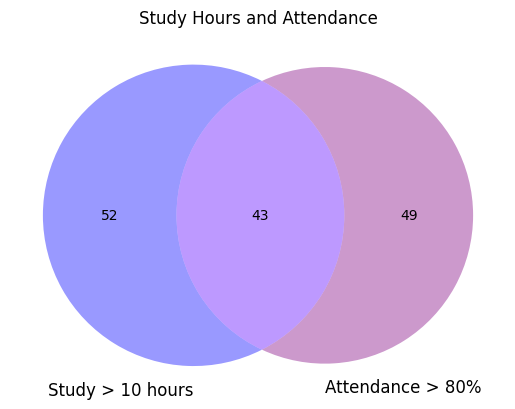

In [36]:
from matplotlib import colors
# Students who study more than 10 hours
aa = len(DF[DF["study_hours"] > 10])

# Students who have more than 80% attendance
bb = len(DF[DF["attendance"] > 80])

# Students who study more than 10 hours AND have more than 80% attendance
c = len(DF[(DF["study_hours"] > 10) & (DF["attendance"] > 80)])

# Study more than 10 hours only
a = aa - c

# Attendance more than 80% only
b = bb - c

# Create Venn diagram
venn2(
    subsets=(a, b, c),
    set_labels=("Study > 10 hours", "Attendance > 80%"),
    set_colors=("blue", "purple")
)

plt.title("Study Hours and Attendance")
plt.show()

# ****Contingency table & Probability Calculation.****

In [28]:
Contingency_table = pd.crosstab(DF["group_discussion"] , DF["final_exam_pass"] , margins=True)
Contingency_table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,76,19,95
Yes,67,38,105
All,143,57,200


# ****Joint Probability.****

# Group Discussion = Yes AND Pass

In [29]:
Contingency_probability = pd.crosstab(DF["group_discussion"] , DF["final_exam_pass"] , margins=True , normalize = "all")
Contingency_probability

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,0.380,0.095,0.475
Yes,0.335,0.190,0.525
All,0.715,0.285,1.000


# ****Marginal Probability.****
# Pass

In [30]:
p = len(DF[DF["final_exam_pass"]=="Pass"]) / len(DF)
print("Probability:" , p)

Probability: 0.285


# ****Conditional Probability.****

In [31]:
yes_students = len(DF[DF["group_discussion"] == "Yes"])

yes_and_pass = len(
    DF[
        (DF["group_discussion"] == "Yes") &
        (DF["final_exam_pass"] == "Pass")
    ])

conditional_probability = yes_and_pass / yes_students

print("Number of students with group discussion:", yes_students)
print("Students with group discussion and Pass:", yes_and_pass)
print("Probability of passing given group discussion:", conditional_probability)
print("Percentage:", conditional_probability * 100, "%")

Number of students with group discussion: 105
Students with group discussion and Pass: 38
Probability of passing given group discussion: 0.3619047619047619
Percentage: 36.19047619047619 %


# ****6. Understanding Relationships.*****
# Conditional Probability Interpretation
# Conditional probability tells us the probability of one event happening when we already know that another event has happened.

# In this project, P(Pass | Group Discussion = Yes) tells us the probability that a student passes the exam among students who participated in group discussions.

# ***Independent or Dependent ?***
# Two events are independent when the occurrence of one event does not affect the probability of the other event.

# ****We compare:****

# P(Pass | Group Discussion = Yes)

# with

# P(Pass)

# If the values are different, it suggests that the two events are dependent.

# Mutually Exclusive?
# The events are not mutually exclusive because a student can participate in group discussion and also pass the exam.

In [32]:
pass_probability = len(
    DF[DF["final_exam_pass"] == "Pass"]
) / len(DF)

print("P(Pass):", pass_probability*100,"%")
print("P(Pass | Group Discussion = Yes):", conditional_probability*100,"%")

P(Pass): 28.499999999999996 %
P(Pass | Group Discussion = Yes): 36.19047619047619 %


# ****7. Bayes Theorem.****

# Given:

# P(High Attendance | Pass) = 0.45

# P(High Attendance | Fail) = 0.17

# P(High Attendance) = 0.375

# We need to find:

# P(Pass | High Attendance)

In [33]:
P_high_given_pass = 0.45
P_high_given_fail = 0.17
P_high = 0.375

P_pass = (P_high - P_high_given_fail) / (P_high_given_pass - P_high_given_fail)

P_fail = 1 - P_pass

P_pass_given_high = (P_high_given_pass * P_pass) / P_high

print("P(Pass):", P_pass)
print("P(Fail):", P_fail)
print("P(Pass | High Attendance):", P_pass_given_high)

P(Pass): 0.732142857142857
P(Fail): 0.267857142857143
P(Pass | High Attendance): 0.8785714285714284


# Final Summary

# #This project focuses on understanding and applying probability concepts to student performance data using Python. The analysis includes basic probability, empirical and theoretical probability, random variables, probability distributions, Venn diagrams, contingency tables, joint probability, marginal probability, conditional probability, and Bayes' theorem.

#The dataset contains 200 student records. The analysis shows that 28.5% of students passed the final exam, while 71.5% failed. The empirical probability of passing was 28%, which is close to the theoretical probability of 28.5%.

#The probability distribution for three randomly selected students gives an expected number of 0.855 students passing. The contingency table shows that 38 out of 105 students who participated in group discussions passed the exam, resulting in a conditional passing probability of approximately 36.19%.

#Using Bayes' theorem, the calculated probability of passing given high attendance is approximately 87.86%, based on the probabilities specified in the notebook.

#In conclusion, this project demonstrates how Python can be used to calculate probabilities, analyze relationships between student activities and exam results, and interpret statistical outcomes. These techniques help develop a better understanding of probability and data-driven decision-making.
